In [1]:
import pandas as pd
import numpy as np

In [2]:
df_test = pd.read_csv('datasets/real data/interactions_by_msoa_pair_and_time_2019_directional.csv')

df_test.head()

,origin_msoa11cd,destination_msoa11cd,hour,flow_sum
0,E02000001,E02000001,0,520
1,E02000192,E02000001,0,13
2,E02000193,E02000001,0,20
3,E02000371,E02000001,0,85
4,E02000575,E02000001,0,33


In [3]:
import geopandas as gpd

#load data
path= "datasets/real data/MSOA_Dec_2011_Boundaries_Generalised_Clipped_BGC_EW_V3_2022_-5342298291295739459.zip"
msoas = gpd.read_file(path)


msoas = msoas.to_crs(epsg=6933)
msoas.head()

msoas['area_km2'] = msoas.geometry.area / 1e6

area = msoas[['MSOA11CD', 'area_km2']].copy()


In [7]:
msoas.head(400)

,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,area_km2
0,E02000001,City of London 001,City of London 001,532378,181354,-0.093570,51.5156,7e1c3fbc-cc47-4e16-a505-d89e93921c28,"POLYGON ((-9338.505 5737960.092, -9308.083 573...",2.907269
1,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,548267,189693,0.138759,51.5866,9f32701c-7edc-4f73-b8c2-a1afac813fbb,"POLYGON ((14288.183 5743840.3, 14285.824 57438...",2.166595
2,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,548259,188522,0.138150,51.5761,7687f18e-6c8e-4afb-9c98-a9e633e00dd6,"POLYGON ((14533.356 5742743.762, 14316.827 574...",2.143995
3,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,551004,186418,0.176830,51.5564,67259638-dce5-461c-82f7-8fbac8335b66,"POLYGON ((17857.76 5741283.861, 17753.335 5741...",2.491928
4,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,548733,186827,0.144269,51.5607,dadad0f1-384f-4686-9535-5026812db2a9,"POLYGON ((14461.177 5741545.365, 14545.818 574...",1.186290
...,...,...,...,...,...,...,...,...,...,...
395,E02000411,Haringey 015,Haringey 015,534641,189817,-0.057740,51.5911,469ad459-267c-45c3-aea1-b87ae19ce64a,"POLYGON ((-5136.209 5744267.854, -5034.976 574...",1.384605
396,E02000412,Haringey 016,Haringey 016,531073,189949,-0.109170,51.5932,d87c98c7-e490-4482-bb9d-702e36676a78,"POLYGON ((-10154.895 5743823.501, -10358.341 5...",0.774950
397,E02000413,Haringey 017,Haringey 017,528079,189436,-0.152550,51.5892,6d4e3223-0e0d-40c6-96e5-0e22daf5cd4a,"POLYGON ((-14658.443 5743944.397, -14606.182 5...",1.224901
398,E02000414,Haringey 018,Haringey 018,533155,189773,-0.079200,51.5911,57b61786-ec27-44a8-b407-8d7203c8aeff,"POLYGON ((-7622.609 5743623.544, -7603.452 574...",0.412343


In [4]:
#cast to string
df_test['origin_msoa11cd'] = df_test['origin_msoa11cd'].astype(str)
df_test['destination_msoa11cd'] = df_test['destination_msoa11cd'].astype(str)
area['MSOA11CD'] = area['MSOA11CD'].astype(str)

df_merged = df_test.merge(area[['MSOA11CD', 'area_km2']], left_on='origin_msoa11cd', right_on='MSOA11CD', how='left')
df_merged.head()

,origin_msoa11cd,destination_msoa11cd,hour,flow_sum,MSOA11CD,area_km2
0,E02000001,E02000001,0,520,E02000001,2.907269
1,E02000192,E02000001,0,13,E02000192,0.432526
2,E02000193,E02000001,0,20,E02000193,1.086997
3,E02000371,E02000001,0,85,E02000371,0.996142
4,E02000575,E02000001,0,33,E02000575,0.930778


In [5]:
df_merged= df_merged.drop(columns=['MSOA11CD'])
#df_merged['area_km2'].sum()

In [6]:

# 1. Load the official UK Postcode Lookup file (downloaded from the ONS portal)
# 'pcds' = The full postcode (e.g., "SW1A 1AA")
# 'msoa21' = The 2021 MSOA ID (e.g., "E02000001")
postcodes = pd.read_csv('datasets/real data/NSPL_NOV_2019_UK.csv')

#
# # 3. Find the DOMINANT Postcode District for each MSOA
# # Since an MSOA might contain postcodes from SW1A and SW1B, we group by the MSOA
# # and use .mode() to find the most common postcode district inside it.
active_zones = pd.concat([df_merged['origin_msoa11cd'], df_merged['destination_msoa11cd']]).unique()
postcodes_london = postcodes[postcodes['msoa11'].isin(active_zones)]
postcodes_london['postcode_district'] = postcodes_london['pcds'].str.split(' ').str[0]
dominant_mapping = postcodes_london.groupby('msoa11')['postcode_district'].agg(lambda x: x.mode()[0]).reset_index()

# 5. Rename it back to 'pcd' so the rest of your downstream merging code works perfectly without changes
dominant_mapping = dominant_mapping.rename(columns={'postcode_district': 'pcd'})
#
# print(dominant_mapping.head())

/var/folders/nr/npwcl3b53m7d_lm5jnd6qqt40000gn/T/ipykernel_62373/3701358684.py:4: DtypeWarning: Columns (31,36) have mixed types. Specify dtype option on import or set low_memory=False.
  postcodes = pd.read_csv('datasets/real data/NSPL_NOV_2019_UK.csv')
/var/folders/nr/npwcl3b53m7d_lm5jnd6qqt40000gn/T/ipykernel_62373/3701358684.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  postcodes_london['postcode_district'] = postcodes_london['pcds'].str.split(' ').str[0]


In [7]:
len(active_zones)

983

In [97]:
dominant_mapping

,msoa11,pcd
0,E02000001,EC2M
1,E02000002,RM6
2,E02000003,RM6
3,E02000004,RM7
4,E02000005,RM8
...,...,...
978,E02006927,SE3
979,E02006928,SE10
980,E02006929,SE10
981,E02006930,SE10


unmapped

In [163]:

# 1. Create integer index mapping for node



df_merged = df_merged [df_merged['destination_msoa11cd'].isin(df_merged['origin_msoa11cd'].unique())]


all_nodes = pd.concat([df_merged['origin_msoa11cd'], df_merged['destination_msoa11cd']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)


ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]


population = (df_merged.groupby('origin_msoa11cd')['flow_sum'].sum()).reset_index()
population= population.rename(columns= {'flow_sum' : 'total_populaiton'})
df_merged_pop = df_merged.merge(population, on='origin_msoa11cd', how='left')

total_flows = df_merged_pop.groupby(['origin_msoa11cd', 'destination_msoa11cd'])['flow_sum'].sum().reset_index()
total_flows= total_flows.rename(columns= {'flow_sum' : 'total_flow'})
df_merged_pop = df_merged_pop.merge(total_flows, on=['origin_msoa11cd', 'destination_msoa11cd'], how='left')





# 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_merged_pop.drop_duplicates('origin_msoa11cd')
                .set_index('origin_msoa11cd')['area_km2']
                .reindex(ordered_geoids)
                .fillna(0)
                .values) *  0.386


area_distr.sum()


607.5636324355117

Mapped

In [8]:
df_mapped = df_merged.merge(
    dominant_mapping,
    left_on='origin_msoa11cd',
    right_on='msoa11',
    how='inner'
)
# Rename the new column so we know it belongs to the origin
df_mapped = df_mapped.rename(columns={'pcd': 'zip_org'})
# Drop the extra msoa column to keep things clean
df_mapped = df_mapped.drop(columns=['msoa11'])

# 2. Merge the mapping onto the DESTINATION column
df_mapped = df_mapped.merge(
    dominant_mapping,
    left_on='destination_msoa11cd',
    right_on='msoa11',
    how='inner'
)


# Rename the new column so we know it belongs to the destination
df_mapped = df_mapped.rename(columns={'pcd': 'zip_dest'})
df_mapped = df_mapped.drop(columns=['msoa11'])
#
#
#
# # 2. Group by the Postcode District and SUM the areas
unique_zips = df_mapped.drop_duplicates('origin_msoa11cd')
zipcode_areas = unique_zips.groupby('zip_org')['area_km2'].sum().reset_index()


# 3. Group by the new postcode districts and SUM the flows
total_flows = df_mapped.groupby(['zip_org', 'zip_dest'])['flow_sum'].sum().reset_index()
#

population = (total_flows.groupby('zip_org')['flow_sum'].sum()).reset_index(name = 'population')
population['population'] = population['population'].clip(lower=80)
df_flows_pop = total_flows.merge(population, on='zip_org', how='left')

df_flows_pop = df_flows_pop.merge(zipcode_areas, on='zip_org', how='left')


all_nodes = pd.concat([df_flows_pop['zip_org'], df_flows_pop['zip_dest']]).unique()
node_to_idx = {node: idx for idx, node in enumerate(all_nodes)}
number_nodes = len(all_nodes)


ordered_geoids = [geoid for geoid, idx in sorted(node_to_idx.items(), key=lambda x: x[1])]



# # 3. Area — one area per geoid_o, reindex to same order
area_distr = (df_flows_pop.drop_duplicates('zip_org')
                .set_index('zip_org')['area_km2']
                .reindex(ordered_geoids)
                .fillna(0)
                .values) *  0.386


area_distr.sum()



607.5636324355119

In [9]:
# df_merged_pop = df_merged_pop[((df_merged_pop['total_flow'] >= df_merged_pop['total_populaiton'] * 0.01) | (df_merged_pop['total_flow'] >=100))]
#
# df_merged_pop = df_merged_pop[(df_merged_pop['total_flow'] >= df_merged_pop['total_populaiton'] * 0.01)]
df_merged_pop = df_merged_pop.drop(columns = ['hour', 'flow_sum'])
df_merged_pop = df_merged_pop.drop_duplicates()


NameError: name 'df_merged_pop' is not defined

In [77]:
df_merged_pop

,origin_msoa11cd,destination_msoa11cd,area_km2,total_populaiton,total_flow
0,E02000001,E02000001,2.907269,175502,84468
1,E02000192,E02000001,0.432526,10962,1602
2,E02000193,E02000001,1.086997,47591,2999
3,E02000371,E02000001,0.996142,22058,3410
4,E02000575,E02000001,0.930778,22597,3041
...,...,...,...,...,...
195768,E02000884,E02006925,0.545287,8437,10
195772,E02006798,E02006927,0.826550,14534,12
195779,E02000083,E02006929,3.734652,8046,39
195780,E02000085,E02006929,1.627210,3426,20


In [36]:
import numpy as np
from scipy.sparse import coo_matrix
#
#
# rows = df_merged_pop['origin_msoa11cd'].map(node_to_idx).values
# cols = df_merged_pop['destination_msoa11cd'].map(node_to_idx).values
#
# # 3. Compute weight = fraction of origin population that flows to destination
# #    pop_flows / total_pop gives: "X% of node i's population goes to node j"
# weights = (df_merged_pop['total_flow'] / df_merged_pop['total_populaiton']).values
#
# # 4. Build sparse matrix
# graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
# #graph = graph.tocsr()




rows = df_flows_pop['zip_org'].map(node_to_idx).values
cols = df_flows_pop['zip_dest'].map(node_to_idx).values

# 3. Compute weight = fraction of origin population that flows to destination
#    pop_flows / total_pop gives: "X% of node i's population goes to node j"
weights = (df_flows_pop['flow_sum'] / df_flows_pop['population']).values

# 4. Build sparse matrix
graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
#graph = graph.tocsr()

weights

#df_merged_pop

array([0.62843622, 0.10388588, 0.02864611, ..., 0.0195205 , 0.00296275,
       0.33796306])

In [10]:
import scipy.sparse as sp

# Assuming 'graph' is your csr_matrix
sp.save_npz('testing graphs/mobility_graph_london.npz', graph)

In [166]:
print("node_to_idx size:", len(node_to_idx))
print("unique geoid_o in df_merged_pop:", df_merged_pop['origin_msoa11cd'].nunique())
print("unique geoid_d in df_merged_pop:", df_merged_pop['destination_msoa11cd'].nunique())

# Find the offending node
in_idx_not_in_origins = set(node_to_idx.keys()) - set(df_merged_pop['origin_msoa11cd'].unique())
print("nodes in graph but not in origins:", in_idx_not_in_origins)

node_to_idx size: 983
unique geoid_o in df_merged_pop: 983
unique geoid_d in df_merged_pop: 983
nodes in graph but not in origins: set()


In [12]:
def calculte_m(area_distr, eff_population, graph, mobility_rate):
    c = 2e-4
    f =  2 - np.exp(-c*(eff_population / area_distr))

    f_neff = f / eff_population

    #m1 and m2 are 0 if p=1

    m1 = ((1-mobility_rate) **2) * f_neff
    m1 = np.diag(m1) #kronegers thing makes it a diagonal


    #r_ij multipleid by f/neff_j
    term_1 = graph.multiply(f_neff[np.newaxis, :])
    #r_ji (same as transpose term 1)
    term_2 = graph.T.multiply(f_neff[:, np.newaxis])
    m2 = mobility_rate * (1-mobility_rate) * (term_1 + term_2).toarray()

    #ril * nf_neff is same as term 1, then matrix mult with transpose to get m3
    m3= (mobility_rate**2) * (term_1 @ graph.T).toarray()

    return m1 + m2 + m3

In [37]:
from scipy.linalg import eig

def generate_data(input_graph,input_area_distr, recovery_rate, population, mobility_rate = 1,):
    graph = input_graph
    #visualise_graph(graph)

        #calculat eff population formula 6 from papaer

    eff_population = (1 - mobility_rate) * population + mobility_rate * np.array(graph.T.dot(population)).flatten()
    eff_population[eff_population == 0] = 1

    #devide area acording to log-linear dist

    area_distr = input_area_distr
    area_distr[area_distr == 0] = 1




    matrix_m = calculte_m(area_distr, eff_population, graph, 1)
    matrix_m = matrix_m * population[np.newaxis, :]

     # --- diagnostics ---
    print("area_distr NaNs:", np.isnan(area_distr).sum(), "zeros:", (area_distr == 0).sum())
    print("eff_population NaNs:", np.isnan(eff_population).sum())
    print("population NaNs:", np.isnan(population).sum())
    print("matrix_m NaNs:", np.isnan(matrix_m).sum(), "Infs:", np.isinf(matrix_m).sum())

    eigenvalues, _ = eig(matrix_m)
    spectral_radius = np.max(np.abs(eigenvalues))


    # -------------------

    # matrix_m_2 = calculte_m(area_distr, eff_population, graph, 0)
    #
    # eigenvalues_2, _ = eigs(matrix_m_2, k=1, which='LM')
    # spectral_radius_2 = np.abs(eigenvalues_2[0])

    print(spectral_radius)
    # print(spectral_radius_2)



    print(recovery_rate / spectral_radius)
    return recovery_rate / spectral_radius

#
# population = (df_merged_pop.drop_duplicates('origin_msoa11cd')
#                            .set_index('origin_msoa11cd')['total_populaiton']
#                            .reindex(ordered_geoids)
#                            .fillna(0)
#                            .astype(float)
#                            .values)


population = (df_flows_pop.drop_duplicates('zip_org')
                           .set_index('zip_org')['population']
                           .reindex(ordered_geoids)
                           .fillna(0)
                           .astype(float)
                           .values)

threshold = generate_data(graph, area_distr, 1, population, 1)



area_distr NaNs: 0 zeros: 0
eff_population NaNs: 0
population NaNs: 0
matrix_m NaNs: 0 Infs: 0
1.9370660589616648
0.516244655350595


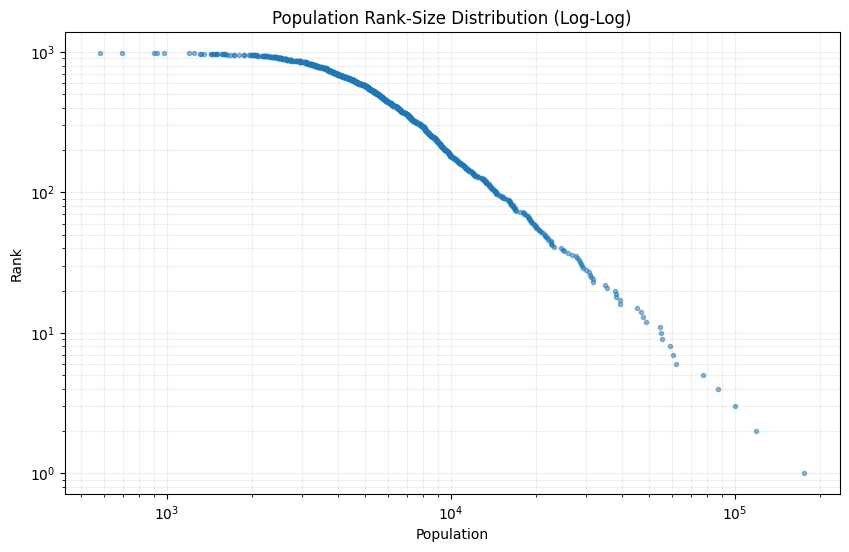

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Sort population from largest to smallest
sorted_pop = np.sort(population)[::-1]
ranks = np.arange(1, len(sorted_pop) + 1)

plt.figure(figsize=(10, 6))
plt.loglog(sorted_pop, ranks, marker='.', linestyle='none', alpha=0.5)
plt.title("Population Rank-Size Distribution (Log-Log)")
plt.ylabel("Rank")
plt.xlabel("Population")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In [170]:
population.sum()

8064392.0

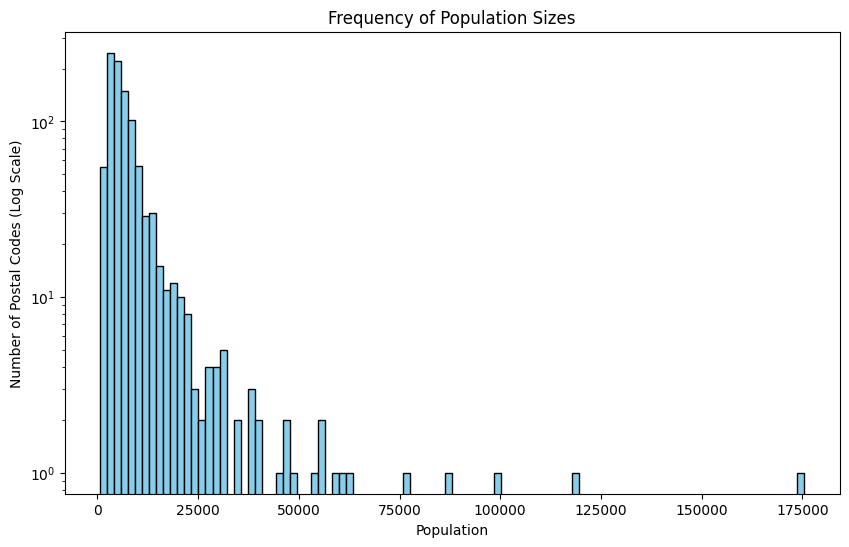

In [169]:
 import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(population, bins=100, color='skyblue', edgecolor='black', log=True)
plt.title("Frequency of Population Sizes")
plt.xlabel("Population")
plt.ylabel("Number of Postal Codes (Log Scale)")
plt.show()

In [73]:
population.sum()

origin_msoa11cd     E02000001E02000002E02000003E02000004E02000005E...
total_populaiton                                              8064392
dtype: object

In [40]:
np.savez_compressed('testing graphs/mobility_metadata_real.npz',
                    population=population)

In [152]:

import torch
from torch_geometric.data import Data
import numpy as np
import os



edge_index = torch.tensor(np.vstack((graph.row, graph.col)), dtype=torch.long)

# 2. edge_attr: Shape [num_edges, 1], type float32
edge_attr = torch.tensor(graph.data, dtype=torch.float32).view(-1, 1)

# 3. x (Node features): Combine population and position, Shape [num_nodes, 3], type float32
node_features = np.column_stack((population, area_distr, positions))
x = torch.tensor(node_features, dtype=torch.float32)

# 4. y (Target label): Shape [1], type float32
y = torch.tensor([threshold], dtype=torch.float32)

# --- Construct PyG Data Object ---
data_obj = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Append to our list
pyg_graph = data_obj

save_path = '/Users/emmapinckers/PycharmProjects/thesis/data generation/datasets/version1/london.pt'

torch.save(pyg_graph, save_path)




In [15]:
import geopandas as gpd

#load data
path= "datasets/real data/MSOA_Dec_2011_PWC_in_England_and_Wales_2022_-4778813801309868785.zip"
coords = gpd.read_file(path)


coords = coords.to_crs(epsg=6933)
coords.head()

# msoas['area_km2'] = msoas.geometry.area / 1e6
#
# area = msoas[['MSOA11CD', 'area_km2']].copy()

,msoa11cd,msoa11nm,GlobalID,geometry
0,E02002536,Stockton-on-Tees 002,fbe686da-fa3b-4b02-9c8a-cfb35447770c,POINT (-125022.928 5976638.885)
1,E02002537,Stockton-on-Tees 003,f9dc93c1-880b-482d-8221-84114e3aad4e,POINT (-123236.928 5976685.285)
2,E02002534,Redcar and Cleveland 020,c5cf6cca-ad8e-417a-b70d-0d39802c817d,POINT (-101642.712 5970442.17)
3,E02002535,Stockton-on-Tees 001,8257edfb-24ea-4098-bf35-024defd9dfb4,POINT (-124204.837 5977492.843)
4,E02002532,Redcar and Cleveland 018,67c75ba4-46a8-461b-ab1f-e4951ec488ea,POINT (-102074.361 5971153.9)


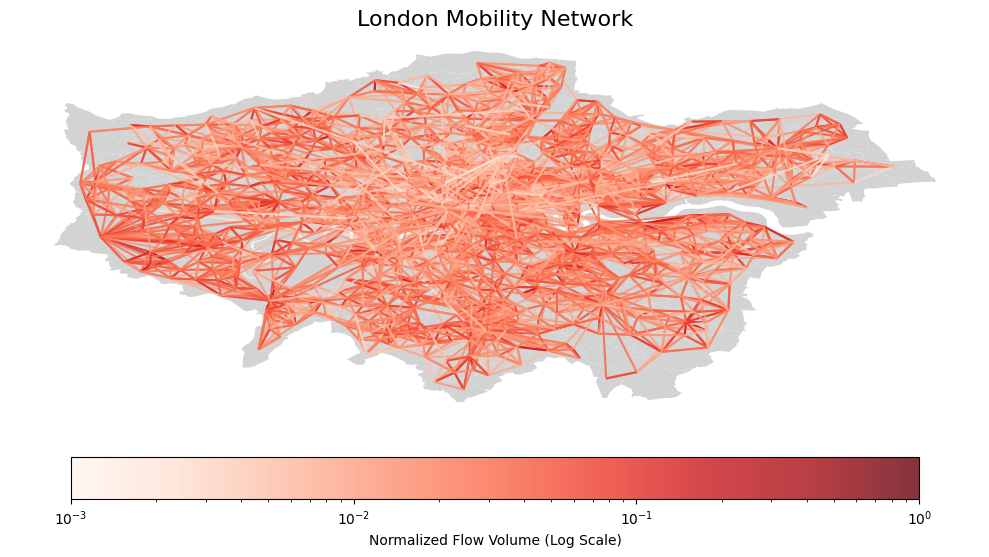

In [78]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
from shapely.geometry import LineString
import warnings


msoas['centroid'] = msoas.geometry.centroid
coords = dict(zip(msoas['MSOA11CD'], zip(msoas['centroid'].x, msoas['centroid'].y)))

# ==========================================
# 2. PROCESS THE OD MATRIX
# ==========================================
# Filter out self-loops (flows within the same MSOA)
df_OD = df_merged_pop.copy()
df_OD = df_OD[df_OD['origin_msoa11cd'] != df_OD['destination_msoa11cd']]

active_zones = pd.concat([df_OD['origin_msoa11cd'], df_OD['destination_msoa11cd']]).unique()
msoas_london = msoas[msoas['MSOA11CD'].isin(active_zones)]


df_OD = df_OD[(df_OD['total_flow'] >= df_OD['total_populaiton'] * 0.02)]
max_flow = df_OD['total_flow'].max()
df_OD['normalized_flow'] = (df_OD['total_flow'] / max_flow)
# df_OD = df_OD[~(df_OD['normalized_flow'] <= 0.01)]

df_OD = df_OD.drop(columns = {'area_km2', 'total_populaiton', 'total_flow'})
# df_OD


lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['origin_msoa11cd']
    dest = row['destination_msoa11cd']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])


fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the Base Map (Non-hotspots as solid Light Gray)
msoas_london.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    markersize=15,# Adjust size if needed
    zorder=1
)


# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10**-3, vmax=10**0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2          # Lines go on top of the polygons
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'London Mobility Network', fontsize=16)
ax.set_axis_off() # Removes the bounding box and coordinates

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)') #normalized by largest flow!!!!!!
# Lock the aspect ratio so the map doesn't stretch
# ax.set_aspect('equal')

plt.tight_layout()
plt.show()



In [43]:
msoas_mapped

,MSOA11CD,MSOA11NM,MSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,area_km2,msoa11,pcd
0,E02000001,City of London 001,City of London 001,532378,181354,-0.093570,51.5156,7e1c3fbc-cc47-4e16-a505-d89e93921c28,"POLYGON ((-9338.505 5737960.092, -9308.083 573...",2.907269,E02000001,E1 6AN
1,E02000002,Barking and Dagenham 001,Barking and Dagenham 001,548267,189693,0.138759,51.5866,9f32701c-7edc-4f73-b8c2-a1afac813fbb,"POLYGON ((14288.183 5743840.3, 14285.824 57438...",2.166595,E02000002,RM5 2BG
2,E02000003,Barking and Dagenham 002,Barking and Dagenham 002,548259,188522,0.138150,51.5761,7687f18e-6c8e-4afb-9c98-a9e633e00dd6,"POLYGON ((14533.356 5742743.762, 14316.827 574...",2.143995,E02000003,RM1 1HA
3,E02000004,Barking and Dagenham 003,Barking and Dagenham 003,551004,186418,0.176830,51.5564,67259638-dce5-461c-82f7-8fbac8335b66,"POLYGON ((17857.76 5741283.861, 17753.335 5741...",2.491928,E02000004,RM107AA
4,E02000005,Barking and Dagenham 004,Barking and Dagenham 004,548733,186827,0.144269,51.5607,dadad0f1-384f-4686-9535-5026812db2a9,"POLYGON ((14461.177 5741545.365, 14545.818 574...",1.186290,E02000005,RM107LJ
...,...,...,...,...,...,...,...,...,...,...,...,...
978,E02006927,Greenwich 034,Greenwich 034,540764,175168,0.024735,51.4580,a062a326-05de-4ba9-9cab-4ea7f358a859,"POLYGON ((2795.297 5733518.665, 2887.495 57333...",2.526758,E02006927,SE128AL
979,E02006928,Greenwich 035,Greenwich 035,537902,177439,-0.015540,51.4791,91390d2d-006c-4e6f-8b6a-3054ec217dec,"MULTIPOLYGON (((-2226.098 5734467.37, -2235.87...",0.540724,E02006928,SE108BN
980,E02006929,Greenwich 036,Greenwich 036,540018,179089,0.015558,51.4934,ecbb9dfd-356d-4e36-9470-6919073c856e,"POLYGON ((1559.182 5735760.88, 1786.528 573569...",2.550705,E02006929,SE100AA
981,E02006930,Greenwich 037,Greenwich 037,540116,178336,0.016670,51.4866,e1b550d9-3d3c-46c1-9cb4-8a3eb1c35b0c,"POLYGON ((833.507 5735231.738, 804.739 5735199...",0.868183,E02006930,SE100AF


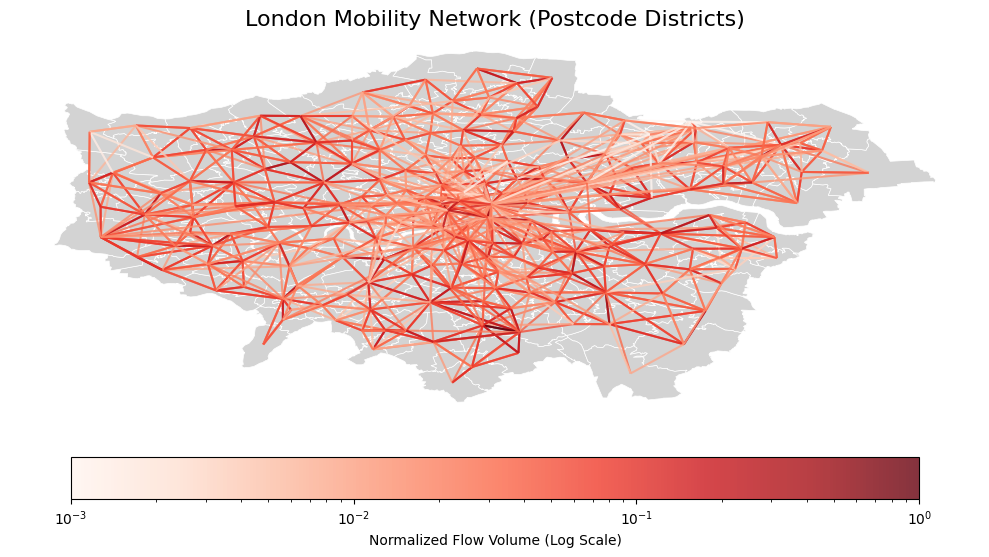

In [18]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm

# ==========================================
# 1. DISSOLVE MSOAS INTO ZIP CODE POLYGONS
# ==========================================
# Merge your translation mapping onto the geographic MSOA map
msoas_mapped = msoas.merge(dominant_mapping, left_on='MSOA11CD', right_on='msoa11', how='inner')

# DISSOLVE: Merge all MSOA polygons that share a zip code into one big polygon
zipcodes_gdf = msoas_mapped.dissolve(by='pcd').reset_index()

# Calculate the new, centralized coordinates for these larger zip code zones
zipcodes_gdf['centroid'] = zipcodes_gdf.geometry.centroid
coords = dict(zip(zipcodes_gdf['pcd'], zip(zipcodes_gdf['centroid'].x, zipcodes_gdf['centroid'].y)))

# ==========================================
# 2. PROCESS THE ZIP CODE OD MATRIX
# ==========================================
# Assuming your aggregated table from earlier is called df_flows_pop
df_OD = df_flows_pop.copy()

# Filter out self-loops (flows within the same zip code)
df_OD = df_OD[df_OD['zip_org'] != df_OD['zip_dest']]

# Filter the map to only show active zones
active_zones = pd.concat([df_OD['zip_org'], df_OD['zip_dest']]).unique()
zipcodes_london = zipcodes_gdf[zipcodes_gdf['pcd'].isin(active_zones)]

# Apply your flow threshold (Adjust column names to match your data if needed)
df_OD = df_OD[(df_OD['flow_sum'] >= df_OD['population'] * 0.01)]

# Normalize the flows based on the largest route
max_flow = df_OD['flow_sum'].max()
df_OD['normalized_flow'] = (df_OD['flow_sum'] / max_flow)

# Build the line geometry
lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['zip_org']
    dest = row['zip_dest']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])

# ==========================================
# 3. DRAW THE MAP
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the new Zip Code Base Map
zipcodes_london.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    edgecolor='white', # Add white borders so you can see the zip code boundaries
    linewidth=0.5,
    zorder=1
)

# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10**-3, vmax=10**0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'London Mobility Network (Postcode Districts)', fontsize=16)
ax.set_axis_off()
ax.set_aspect('equal')

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)')

plt.savefig("london_mobility_map_new.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()



In [74]:
df_OD

,origin_msoa11cd,destination_msoa11cd,hour,flow_sum,normalized_flow
1,E02000192,E02000001,0,13,0.126023
2,E02000193,E02000001,0,20,0.235919
3,E02000371,E02000001,0,85,0.268250
4,E02000575,E02000001,0,33,0.239223
5,E02000576,E02000001,0,23,0.281624
...,...,...,...,...,...
195789,E02006930,E02006929,23,19,0.344163
195790,E02006931,E02006929,23,12,0.063562
195792,E02006929,E02006930,23,50,0.391048
195795,E02000664,E02006931,23,10,0.097860


In [157]:
df_OD = df_merged_pop.copy()
df_OD = df_OD[(df_OD['total_flow'] >=100)]

#df_OD['normalized_flow'] = (df_OD['total_flow'] / df_OD['total_populaiton'])
#df_OD = df_OD[~((df_OD['normalized_flow'] <= 0.01))]

df_OD = df_OD[df_OD['origin_msoa11cd'] != df_OD['destination_msoa11cd']]
#df_OD = df_OD.drop(columns = {'area_km2', 'total_populaiton', 'total_flow'})

df_OD = df_OD[df_OD['origin_msoa11cd'] != df_OD['destination_msoa11cd']]
#
# max_flow = df_OD['total_flow'].max()
# df_OD['normalized_flow'] = (df_OD['total_flow'] / max_flow)
# df_OD = df_OD[~((df_OD['normalized_flow'] <= 0.01))]
#
# df_OD = df_OD.drop(columns = {'area_km2', 'total_populaiton', 'total_flow'})

df_OD

,origin_msoa11cd,destination_msoa11cd,area_km2,total_populaiton,total_flow
1,E02000192,E02000001,0.432526,10962,1602
2,E02000193,E02000001,1.086997,47591,2999
3,E02000371,E02000001,0.996142,22058,3410
4,E02000575,E02000001,0.930778,22597,3041
5,E02000576,E02000001,0.755587,19382,3580
...,...,...,...,...,...
185520,E02000511,E02000547,2.395173,6640,135
189399,E02000222,E02000210,1.852899,5367,100
189949,E02000658,E02000332,0.774939,5303,123
190782,E02000239,E02000550,2.359203,6678,101


In [16]:
def radiation_model(number_nodes, positions, population):
    rows, cols, weights = [], [], []

    for i in range(number_nodes):
        distance = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distance[i] = np.inf
        distance[distance == 0] = 0.1

        #radiation model simini paper
        #flow ij = mi * ( minj/ (mi + sij) * (mi + nj + sij))
        #sij = sum of populations in distance between city i and j minus original

        #change self flow

        all_flows = []
        for j in range(number_nodes):
            if j == i:
                flow = np.random.uniform(0.25, 0.40) * population[i]  #selfflows
            else:
                r_ij = distance[j]
                # print(r_ij)
                # if r_ij > 5000: # distance cutoff
                #     flow = 0
                #     continue
                # else:
                s_ij = population[(distance < r_ij)].sum() - population[i] - population[j]
                s_ij = max(0, s_ij)  #no negative s

                first_term = population[i] * population[j]
                second_term = (population[i] + s_ij) * (population[i] + population[j] + s_ij)
                if second_term > 0:
                    log_flow = np.log(population[i]) + np.log(first_term) - np.log(second_term)
                    flow = np.exp(log_flow)

            all_flows.append(flow)

        #urban scaling theory geoffery west luisbettern court
        # target_k = number_nodes * 0.08
        # k = int(target_k * (population [i]  / np.mean(population))**0.5) #scale based on popualtion
        # k= np.clip(k, 1, 500)
        # top_idx = np.argpartition(all_flows, -k)[-k:]
        # #print(k)

        k = np.random.uniform(0.01, 0.08)
        k = int(k * number_nodes)
        k=200

        top_idx = np.argpartition(all_flows, -k)[-k:]

        for j in top_idx:
            rows.append(i)
            cols.append(j)
            weights.append(all_flows[j])

        #print(flow)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    # weights = weights / row_sums[rows]

    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)





In [19]:
import numpy as np

# 1. Sort both dataframes alphabetically by the zip code name to perfectly align them
zipcodes_gdf = zipcodes_gdf.sort_values(by='pcd').reset_index(drop=True)

# For population, we just want a unique list of zip codes and their populations
pop_table = df_flows_pop[['zip_org', 'population']].drop_duplicates().sort_values(by='zip_org').reset_index(drop=True)

# Check to ensure they match exactly!
assert (zipcodes_gdf['pcd'] == pop_table['zip_org']).all(), "Mismatch between map and population data!"

In [29]:
# Extract the X and Y coordinates from the polygon centroids
x_coords = zipcodes_gdf.geometry.centroid.x.values
y_coords = zipcodes_gdf.geometry.centroid.y.values

# Use column_stack to merge them into a single (N, 2) array: [[x1, y1], [x2, y2]...]
positions = np.column_stack((x_coords, y_coords))

# Extract the population into a simple 1D array
population = pop_table['population'].values

# Define your number of nodes
number_nodes = len(positions)
number_nodes

227

In [32]:
from scipy.sparse import coo_matrix
import numpy as np


def gravity_model(positions, number_nodes, population):
    rows, cols, weights = [], [], []

    for i in range(number_nodes):
        distances = np.sqrt(((positions[i] - positions) ** 2).sum(axis=1))
        distances[i] = np.inf
        distances[distances == 0] = 0.1

        #attraction = g * (m * m) / d^2
        flow = (population[i] * population) / (distances ** 2)
        flow[i] = np.random.uniform(0.25, 0.40) * population[i]
        flow = np.asarray(flow).flatten()
        # print(type(flow))
        # print(np.shape(flow))

        # # only keeo flows above threshold
        # threshold = np.percentile(flow [flow > 0], 90) #threshol is 10% most attractive cities
        # desitnations_index = np.where(flow > threshold)[0]
        #
        # k = np.random.randint(3, 30)

        k = np.random.uniform(0.01, 0.08)
        k = int(k * number_nodes)
        desitnations_index = np.argsort(flow)[-k:]

        k = 200

        # k = np.random.uniform(0.05, 0.12)
        # k= int(k * number_nodes)
        # desitnations_index = np.argpartition(flow, -k)[-k:]

        for j in desitnations_index:
            rows.append(i)
            cols.append(j)
            weights.append(flow[j])
        #print(flow)

    rows = np.array(rows)
    cols = np.array(cols)
    weights = np.array(weights)

    #print(weights)

    row_sums = np.bincount(rows, weights=weights, minlength=number_nodes)
    row_sums[row_sums == 0] = 1
    # weights = weights / row_sums[rows]  #normalis weights
    #print(weights)

    return np.array(rows), np.array(cols), np.array(weights)


In [33]:
from scipy.sparse import coo_matrix

# rows, cols, weights = radiation_model(number_nodes, positions, population)
rows, cols, weights = gravity_model(positions, number_nodes, population)

graph = coo_matrix((weights, (rows, cols)), shape=(number_nodes, number_nodes))
graph = graph.tocsr()

In [145]:
rows, cols, weights = radiation_model(number_nodes, positions, population)

In [149]:
rows, cols, weights = gravity_model(positions, number_nodes, population)

In [150]:
import pandas as pd

# 1. Create the basic DataFrame from your model's output arrays
df_model_flows = pd.DataFrame({
    'origin_idx': rows,
    'dest_idx': cols,
    'flow_volume': weights
})

# 2. Map the integer indices back to your actual Postcode District names
# (Assuming your pop_table or zipcodes_gdf is still sorted in the exact
# same order you used to feed the model)
zone_names = pop_table['zip_org'].values

# Create new columns with the actual names
df_model_flows['zip_org'] = df_model_flows['origin_idx'].map(lambda x: zone_names[x])
df_model_flows['zip_dest'] = df_model_flows['dest_idx'].map(lambda x: zone_names[x])

# 3. Clean up the DataFrame to match your visualization script's expected format
df_model_flows = df_model_flows[['zip_org', 'zip_dest', 'flow_volume']]

# 4. Filter out self-loops (optional, but good for visualization)
df_model_flows = df_model_flows[df_model_flows['zip_org'] != df_model_flows['zip_dest']]

# 2. Merge the population column directly from pop_table
df_model_flows = df_model_flows.merge(
    pop_table[['zip_org', 'population']],
    on='zip_org',
    how='left'
)

print(df_model_flows.head())

  zip_org zip_dest  flow_volume  population
0     BR1     SE10   216.056223      102911
1     BR1     SE18   244.221699      102911
2     BR1      SE9   311.707367      102911
3     BR1     SE13   359.270873      102911
4     BR1      BR2   472.774077      102911


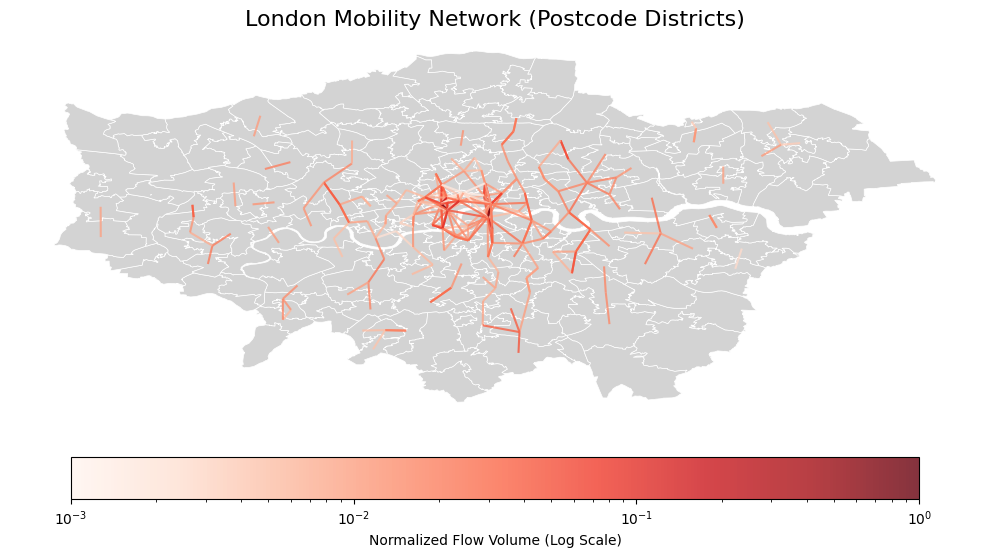

In [151]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm

# ==========================================
# 1. DISSOLVE MSOAS INTO ZIP CODE POLYGONS
# ==========================================
# Merge your translation mapping onto the geographic MSOA map
msoas_mapped = msoas.merge(dominant_mapping, left_on='MSOA11CD', right_on='msoa11', how='inner')

# DISSOLVE: Merge all MSOA polygons that share a zip code into one big polygon
zipcodes_gdf = msoas_mapped.dissolve(by='pcd').reset_index()

# Calculate the new, centralized coordinates for these larger zip code zones
zipcodes_gdf['centroid'] = zipcodes_gdf.geometry.centroid
coords = dict(zip(zipcodes_gdf['pcd'], zip(zipcodes_gdf['centroid'].x, zipcodes_gdf['centroid'].y)))

# ==========================================
# 2. PROCESS THE ZIP CODE OD MATRIX
# ==========================================
# Assuming your aggregated table from earlier is called df_flows_pop
df_OD = df_model_flows.copy()

# Filter out self-loops (flows within the same zip code)
df_OD = df_OD[df_OD['zip_org'] != df_OD['zip_dest']]

# Filter the map to only show active zones
active_zones = pd.concat([df_OD['zip_org'], df_OD['zip_dest']]).unique()
zipcodes_london = zipcodes_gdf[zipcodes_gdf['pcd'].isin(active_zones)]

# Apply your flow threshold (Adjust column names to match your data if needed)
df_OD = df_OD[(df_OD['flow_volume'] >= df_OD['population'] * 0.01)]

# Normalize the flows based on the largest route
max_flow = df_OD['flow_volume'].max()
df_OD['normalized_flow'] = (df_OD['flow_volume'] / max_flow)

# Build the line geometry
lines = []
flow_values = []

for _, row in df_OD.iterrows():
    orig = row['zip_org']
    dest = row['zip_dest']

    # Only draw lines if we have the coordinates for both origin and destination
    if orig in coords and dest in coords:
        lines.append([coords[orig], coords[dest]])
        flow_values.append(row['normalized_flow'])

# ==========================================
# 3. DRAW THE MAP
# ==========================================
fig, ax = plt.subplots(figsize=(10, 10))

# A. Plot the new Zip Code Base Map
zipcodes_london.plot(
    ax=ax,
    color='#D3D3D3',  # Light Gray
    edgecolor='white',  # Add white borders so you can see the zip code boundaries
    linewidth=0.5,
    zorder=1
)

# C. Plot the Mobility Network (Lines)
lc = LineCollection(
    lines,
    cmap='Reds',
    norm=LogNorm(vmin=10 ** -3, vmax=10 ** 0),
    linewidths=1.5,
    alpha=0.8,
    zorder=2
)
lc.set_array(np.array(flow_values))
ax.add_collection(lc)

# D. Formatting
plt.title(r'London Mobility Network (Postcode Districts)', fontsize=16)
ax.set_axis_off()
ax.set_aspect('equal')

# E. Add Colorbar
cbar = plt.colorbar(lc, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
cbar.set_label('Normalized Flow Volume (Log Scale)')

plt.savefig("london_mobility_map_grvaity.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

